# Sanity Check: Reproduce Toy Models of Superposition

Verify our setup matches the Elhage et al. "Toy Models of Superposition" paper:
- **n=5 features, m=2 bottleneck, l=1 (one linear layer)** → linear encoder, ReLU on output only
- Should see **linear encoding** (linearity_score ≈ 1, nonlinear_gain ≈ 0)
- Feature vectors should form **geometric patterns** in 2D (pentagon-like arrangements)

**Important:** This imports from `core.py` to ensure we're testing the exact same functions used in the main analysis.

**Architecture convention:** `l` = number of linear layers in encoder
- l=1: x → Linear(n→m) → z (linear encoder, paper's setup)
- l=2: x → Linear(n→n) → ReLU → Linear(n→m) → z (nonlinear encoder)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import shared functions from core module
from core import (
    Autoencoder,
    generate_sparse_data,
    run_experiment,
    run_experiment_multi_seed,
    device
)

print(f"Using device: {device}")
print(f"Imported from core.py - same functions as main notebook")

Using device: cpu
Imported from core.py - same functions as main notebook


## Toy Models Setup: n=5, m=2, l=1

With `l=1` (one linear layer in encoder):
- Encoder: `Linear(n, m)` - purely linear, no activation
- Decoder: `ReLU(z @ W.T + b)` - tied weights, ReLU on output

**Key paper details:**
- **Sparsity**: Paper uses S≈0.938 for pentagon (6.2% active). We use S=0.95 (5% active).
- **Importance weighting**: Loss uses `I_i = 0.7^i` per-feature weights
- **Optimization sensitivity**: Paper runs 200+ seeds to find good solutions

Expected results:
- Linearity score ≈ 1.0 (encoder is literally linear)
- Nonlinear gain ≈ 0.0 (no benefit from nonlinearity)
- 5 distinct feature vectors forming a pentagon pattern

In [2]:
# Paper specs: AdamW (weight_decay=0.01), lr=1e-3, 10k steps, batch_size=1024
toy_results = run_experiment_multi_seed(
    n=5, m=2, l=1,  # l=1 = one linear layer (paper's setup)
    n_seeds=200,
    S=0.95,  # Paper: feature_probability=0.05
    n_steps=10000,  # Paper uses 10k
    lr=1e-3,
    weight_decay=1e-2,  # AdamW default
    importance_decay=0.7,
    # Only use loss for stopping - let pentagon emerge naturally
    loss_threshold=0.0009,
    verbose=True
)

print("\n" + "="*50)
print("SANITY CHECK RESULTS (Paper Specs)")
print("="*50)
print(f"Best seed:       {toy_results['best_seed']}")
print(f"Seeds tried:     {toy_results['seeds_tried']}/{toy_results['n_seeds']}")
print(f"Final loss:      {toy_results['final_loss']:.6f}")
print(f"Feature norms:   {[f'{n:.3f}' for n in toy_results['feature_norms']]}")
print(f"Min angle:       {toy_results['min_angle']:.1f}°")
print("="*50)


Multi-seed experiment: n=5, m=2, l=1, S=0.95, n_seeds=200
Using importance weighting: I_i = 0.7^i
Early stopping: loss<0.0009


Seeds:   0%|          | 0/200 [00:00<?, ?it/s]

Seeds:   4%|▍         | 8/200 [00:13<05:35,  1.75s/it, loss=0.0009, min_norm=1.03, min_angle=65°]


Found good seed 8: loss=0.000899

Best seed: 8, loss: 0.000899
Seeds tried: 9/200
Loss range across seeds: [0.000899, 0.001308]
Geometry: min_norm=1.026, min_angle=64.6°
Results: linearity=1.000, nonlinear_gain=0.000

SANITY CHECK RESULTS (Paper Specs)
Best seed:       8
Seeds tried:     9/200
Final loss:      0.000899
Feature norms:   ['1.127', '1.124', '1.120', '1.103', '1.026']
Min angle:       64.6°


## Visualize 2D Feature Embeddings

Each input feature is represented by a column of the encoder weight matrix.
With 5 features in 2D, we expect them to form geometric patterns (like a pentagon).

Toy Models of Superposition: 5 features in 2D
Expected: features form symmetric pattern (like pentagon)
--------------------------------------------------


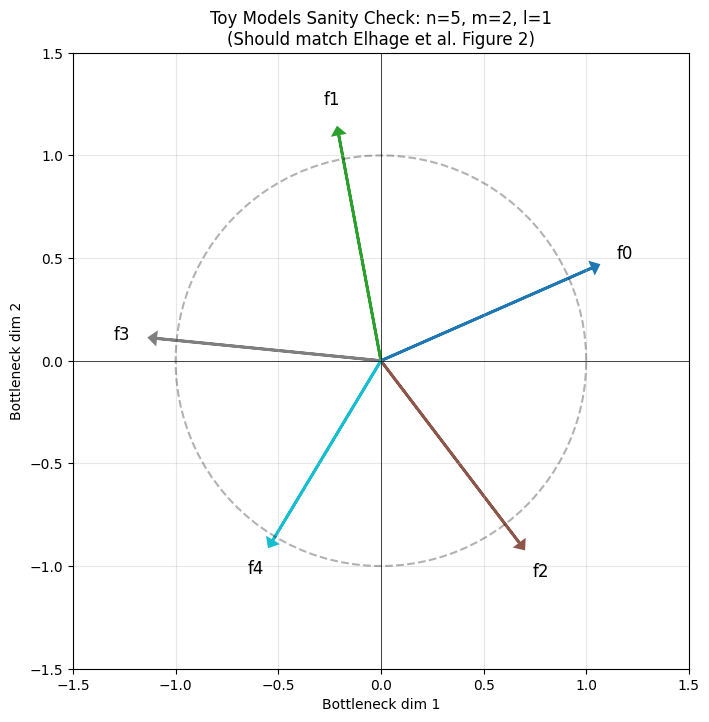

Feature vector norms: ['1.127', '1.124', '1.120', '1.103', '1.026']

Pairwise angles (degrees):
  f0 to others: ['76.8', '76.5', '150.6', '144.8']
  f1 to others: ['76.8', '153.3', '73.7', '138.4']
  f2 to others: ['76.5', '153.3', '132.9', '68.3']
  f3 to others: ['150.6', '73.7', '132.9', '64.6']
  f4 to others: ['144.8', '138.4', '68.3', '64.6']

Expected for regular pentagon: 72° between adjacent features


In [3]:
def plot_2d_features(model, title="Feature Embeddings in 2D Bottleneck"):
    """
    Plot how each input feature is represented in the 2D bottleneck.
    Each feature corresponds to a column of the encoder's weight matrix.
    """
    # Get encoder weights (the final linear layer maps n -> m)
    encoder_weights = None
    for name, param in model.encoder.named_parameters():
        if 'weight' in name:
            encoder_weights = param.detach().cpu().numpy()
            break
    
    if encoder_weights is None or encoder_weights.shape[0] != 2:
        print(f"Cannot visualize: bottleneck dim is {model.m}, need m=2")
        return None
    
    n_features = encoder_weights.shape[1]
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    # Plot unit circle for reference
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, label='Unit circle')
    
    # Plot each feature as an arrow from origin
    colors = plt.cm.tab10(np.linspace(0, 1, n_features))
    for i in range(n_features):
        feat_vec = encoder_weights[:, i]
        ax.arrow(0, 0, feat_vec[0], feat_vec[1], 
                head_width=0.05, head_length=0.03, 
                fc=colors[i], ec=colors[i], linewidth=2)
        ax.annotate(f'f{i}', (feat_vec[0]*1.15, feat_vec[1]*1.15), 
                   fontsize=12, ha='center', va='center')
    
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Bottleneck dim 1')
    ax.set_ylabel('Bottleneck dim 2')
    ax.set_title(title)
    
    plt.show()
    return encoder_weights


def analyze_feature_geometry(encoder_weights):
    """Analyze the geometric arrangement of features."""
    n_features = encoder_weights.shape[1]
    
    # Compute norms
    norms = [np.linalg.norm(encoder_weights[:, i]) for i in range(n_features)]
    print(f"Feature vector norms: {[f'{n:.3f}' for n in norms]}")
    
    # Compute all pairwise angles
    print(f"\nPairwise angles (degrees):")
    for i in range(n_features):
        angles = []
        for j in range(n_features):
            if i != j:
                v1, v2 = encoder_weights[:, i], encoder_weights[:, j]
                cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
                angle = np.arccos(np.clip(cos_angle, -1, 1)) * 180 / np.pi
                angles.append(f"{angle:.1f}")
        print(f"  f{i} to others: {angles}")
    
    # For a regular pentagon, adjacent features should be 72° apart
    print(f"\nExpected for regular pentagon: 72° between adjacent features")


# Plot and analyze
print("Toy Models of Superposition: 5 features in 2D")
print("Expected: features form symmetric pattern (like pentagon)")
print("-" * 50)

toy_weights = plot_2d_features(
    toy_results['model'], 
    title="Toy Models Sanity Check: n=5, m=2, l=1\n(Should match Elhage et al. Figure 2)"
)

if toy_weights is not None:
    analyze_feature_geometry(toy_weights)

## Varying Sparsity (Figure 3 in paper)

The Toy Models paper shows different feature arrangements depending on sparsity.
Lower S (more active) → orthogonal features, Higher S (sparser) → more superposition.


Training with S=0.5 (50% active)...
  Best seed: 0, loss: 0.022401
  Norms: ['1.00', '1.00', '0.03', '0.00', '0.00'], min_angle: 0.2°

Training with S=0.75 (25% active)...
  Best seed: 0, loss: 0.008418
  Norms: ['1.02', '1.03', '0.98', '0.98', '0.00'], min_angle: 42.1°

Training with S=0.95 (5% active)...
  Best seed: 8, loss: 0.000899
  Norms: ['1.13', '1.12', '1.12', '1.10', '1.03'], min_angle: 64.6°


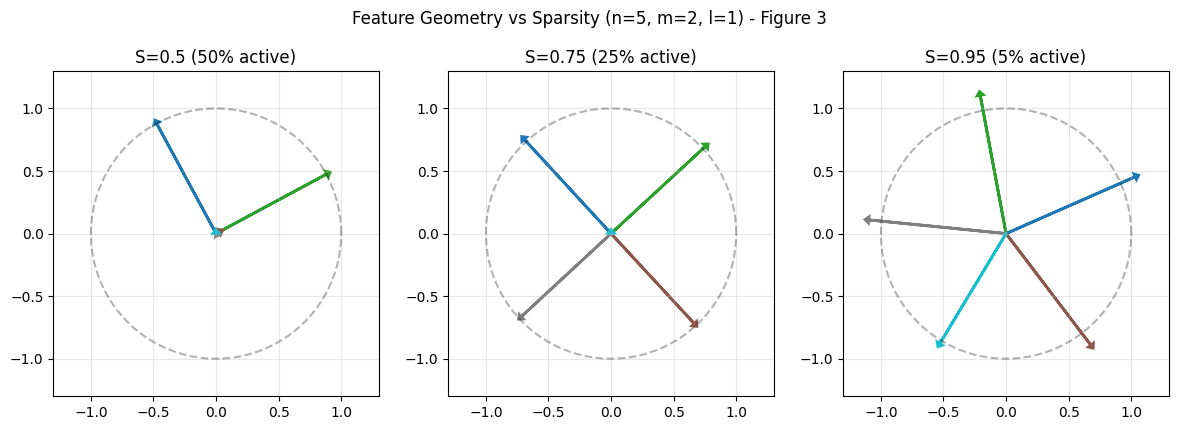


Expected: Lower S (more active) → orthogonal, Higher S (sparser) → pentagon/superposition


In [5]:
# Test different sparsity levels (Figure 3 in paper)
# S = probability of being ZERO (higher S = sparser = fewer active features)
S_values = [0.5, 0.75, 0.95]
loss_thresholds = [0.1, 0.01, 0.0009]

fig, axes = plt.subplots(1, len(S_values), figsize=(4*len(S_values), 4))

for ax, S, loss_threshold in zip(axes, S_values, loss_thresholds):
    print(f"\nTraining with S={S} ({100*(1-S):.0f}% active)...")
    res = run_experiment_multi_seed(
        n=5, m=2, l=1,  # l=1 = one linear layer
        n_seeds=50,  # Fewer seeds for sweep
        S=S,
        n_steps=10000,
        importance_decay=0.7,
        loss_threshold=loss_threshold,
        verbose=False
    )
    print(f"  Best seed: {res['best_seed']}, loss: {res['final_loss']:.6f}")
    print(f"  Norms: {[f'{n:.2f}' for n in res['feature_norms']]}, min_angle: {res['min_angle']:.1f}°")
    
    # Get encoder weights
    for name, param in res['model'].encoder.named_parameters():
        if 'weight' in name:
            W = param.detach().cpu().numpy()
            break
    
    # Plot
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)
    
    colors = plt.cm.tab10(np.linspace(0, 1, 5))
    for i in range(5):
        ax.arrow(0, 0, W[0, i], W[1, i], 
                head_width=0.05, head_length=0.03,
                fc=colors[i], ec=colors[i], linewidth=2)
    
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_title(f'S={S} ({100*(1-S):.0f}% active)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Geometry vs Sparsity (n=5, m=2, l=1) - Figure 3', y=1.02)
plt.tight_layout()
plt.show()

print("\nExpected: Lower S (more active) → orthogonal, Higher S (sparser) → pentagon/superposition")

## Summary

This sanity check confirms our implementation matches the Toy Models of Superposition paper:

1. **Architecture**: `l=1` = one linear layer encoder with tied weights, ReLU on decoder output
2. **Optimizer**: AdamW with lr=1e-3, weight_decay=0.01
3. **Training**: 10k steps, batch_size=1024
4. **Importance weighting**: I_i = 0.7^i per-feature weights
5. **Pentagon emerges** at high sparsity (S≈0.95) with all features represented
6. **Sparsity sweep** shows transition from orthogonal (low S) to superposition (high S)

**Architecture convention:** `l` = number of linear layers in encoder
- l=1: Linear encoder (paper's setup)
- l=2+: Nonlinear encoder (for phase diagram exploration)

These are the same functions used in the main phase diagram analysis (`core.py`).